In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split,cross_val_score,StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay

In [3]:
df=pd.read_csv("blood.csv")

In [4]:
df.head()

,Recency,Frequency,Monetary,Time,Class
0,2,50,12500,98,2
1,0,13,3250,28,2
2,1,16,4000,35,2
3,2,20,5000,45,2
4,1,24,6000,77,1


In [5]:
x=df.drop("Class",axis=1)
y=df["Class"]

In [8]:
models={
    "Logistic Regression":LogisticRegression(),
    "Decision Tree Classifier":DecisionTreeClassifier(),
    "Random Forest CLassifier":RandomForestClassifier(n_estimators=100,random_state=42),
    "Gradient Boosting Classifier":GradientBoostingClassifier(random_state=42),
    "SVC":SVC(),
    "KNeighbors Classifier":KNeighborsClassifier()
}

In [10]:
x_train,x_test,y_train,y_test=train_test_split(x,y,stratify=y,test_size=0.2,random_state=42)

In [11]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

In [12]:
results=[]

In [38]:
for name,model in models.items():
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    accuracy=accuracy_score(y_test,y_pred)
    classification=classification_report(y_test,y_pred)
    confusion=confusion_matrix(y_test,y_pred)
    cv_scores=cross_val_score(model,x,y,cv=cv,scoring="accuracy").mean()
    results.append({"Model":name,"Accuracy Score":accuracy,"Cross Validation Score":cv_scores}) 

In [39]:
results

[{'Model': 'Logistic Regression',
  'Accuracy Score': 0.7666666666666667,
  'Cross Validation Score': array([0.8       , 0.76      , 0.77333333, 0.7852349 , 0.74496644])},
 {'Model': 'Decision Tree Classifer',
  'Accuracy Score': 0.7133333333333334,
  'Cross Validation Score': array([0.67333333, 0.72666667, 0.74      , 0.7114094 , 0.67785235])},
 {'Model': 'Random Forest CLassifier',
  'Accuracy Score': 0.7466666666666667,
  'Cross Validation Score': array([0.71333333, 0.78      , 0.76      , 0.77852349, 0.7114094 ])},
 {'Model': 'Gradient Bossting Classifier',
  'Accuracy Score': 0.7866666666666666,
  'Cross Validation Score': array([0.76666667, 0.8       , 0.78      , 0.7852349 , 0.77181208])},
 {'Model': 'SVC',
  'Accuracy Score': 0.7666666666666667,
  'Cross Validation Score': array([0.76666667, 0.75333333, 0.75333333, 0.77181208, 0.75167785])},
 {'Model': 'KNeighbors Classifier',
  'Accuracy Score': 0.74,
  'Cross Validation Score': array([0.71333333, 0.79333333, 0.76      , 0.812

In [40]:
results_df=pd.DataFrame(results)

In [41]:
results_df

,Model,Accuracy Score,Cross Validation Score
0,Logistic Regression,0.766667,"[0.8, 0.76, 0.7733333333333333, 0.785234899328..."
1,Decision Tree Classifer,0.713333,"[0.6733333333333333, 0.7266666666666667, 0.74,..."
2,Random Forest CLassifier,0.746667,"[0.7133333333333334, 0.78, 0.76, 0.77852348993..."
3,Gradient Bossting Classifier,0.786667,"[0.7666666666666667, 0.8, 0.78, 0.785234899328..."
4,SVC,0.766667,"[0.7666666666666667, 0.7533333333333333, 0.753..."
5,KNeighbors Classifier,0.740000,"[0.7133333333333334, 0.7933333333333333, 0.76,..."
6,Logistic Regression,0.766667,0.772707
7,Decision Tree Classifer,0.706667,0.705852
8,Random Forest CLassifier,0.746667,0.748653
9,Gradient Bossting Classifier,0.786667,0.780743


In [35]:
import matplotlib.pyplot as plt

In [42]:
results_unique = results_df.drop_duplicates(
    subset=["Model"],
    keep="last"
)

results_unique

,Model,Accuracy Score,Cross Validation Score
18,Logistic Regression,0.766667,0.772707
19,Decision Tree Classifer,0.713333,0.70451
20,Random Forest CLassifier,0.746667,0.748653
21,Gradient Bossting Classifier,0.786667,0.780743
22,SVC,0.766667,0.759365
23,KNeighbors Classifier,0.740000,0.762058


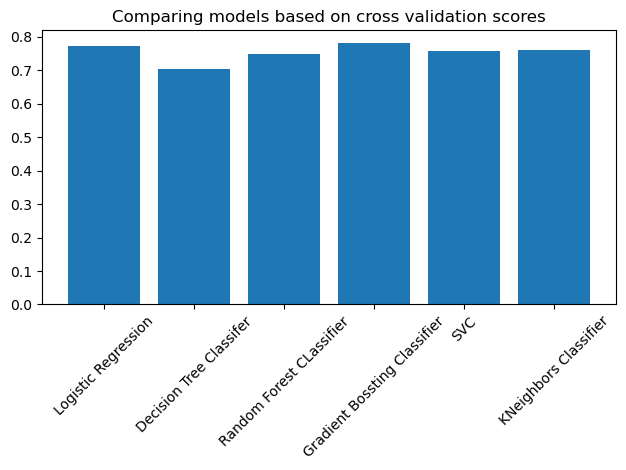

In [56]:
plt.bar(results_unique["Model"],results_unique["Cross Validation Score"])
plt.title("Comparing models based on cross validation scores") 
plt.xticks(rotation=45)
plt.tight_layout()